In [1]:
!pip install yfinance tensorflow scikit-learn seaborn

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [2]:
!pip install numpy==1.23.5 --force-reinstall

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
  Using cached numpy-1.23.5-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (17.1 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
daal4py 2021.5.0 requires daal==2021.4.0, which is not installed.
tensorflow 2.20.0 requires numpy>=1.26.0, but you have numpy 1.23.5 which is incompatible.
numba 0.55.1 requires numpy<1.22,>=1.18, but you have numpy 1.23.5 which is incompatible.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
print("All good!")

Matplotlib is building the font cache; this may take a moment.


All good!


In [4]:
!pip install --upgrade yfinance

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [6]:
import yfinance as yf

df = yf.download('AAPL', start='2015-01-01', end='2024-01-01')
df.reset_index(inplace=True)

print("✅ Data downloaded!")
print("Shape:", df.shape)
print(df.head())

[*********************100%***********************]  1 of 1 completed

✅ Data downloaded!
Shape: (2264, 6)
Price        Date      Close       High        Low       Open     Volume
Ticker                  AAPL       AAPL       AAPL       AAPL       AAPL
0      2015-01-02  24.214893  24.682226  23.776353  24.671151  212818400
1      2015-01-05  23.532721  24.064284  23.346674  23.984549  257142000
2      2015-01-06  23.534935  23.794071  23.173914  23.596950  263188400
3      2015-01-07  23.864948  23.964616  23.632389  23.743131  160423600
4      2015-01-08  24.781898  24.839485  24.075362  24.192751  237458000


In [7]:
# Flatten the multi-level columns
df.columns = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']

print("✅ Columns fixed!")
print(df.head())
print("\nShape:", df.shape)
print("\nBasic Statistics:")
print(df.describe())
print("\nMissing Values:")
print(df.isnull().sum())

✅ Columns fixed!
        Date      Close       High        Low       Open     Volume
0 2015-01-02  24.214893  24.682226  23.776353  24.671151  212818400
1 2015-01-05  23.532721  24.064284  23.346674  23.984549  257142000
2 2015-01-06  23.534935  23.794071  23.173914  23.596950  263188400
3 2015-01-07  23.864948  23.964616  23.632389  23.743131  160423600
4 2015-01-08  24.781898  24.839485  24.075362  24.192751  237458000

Shape: (2264, 6)

Basic Statistics:
             Close         High          Low         Open        Volume
count  2264.000000  2264.000000  2264.000000  2264.000000  2.264000e+03
mean     81.318619    82.142377    80.412963    81.250262  1.237614e+08
std      55.938537    56.511320    55.304137    55.883934  6.818417e+07
min      20.584812    20.887866    20.386576    20.507342  2.404830e+07
25%      32.784022    32.980017    32.603053    32.796164  7.831732e+07
50%      51.172962    51.983522    50.799033    51.319689  1.056556e+08
75%     138.887665   140.572322   

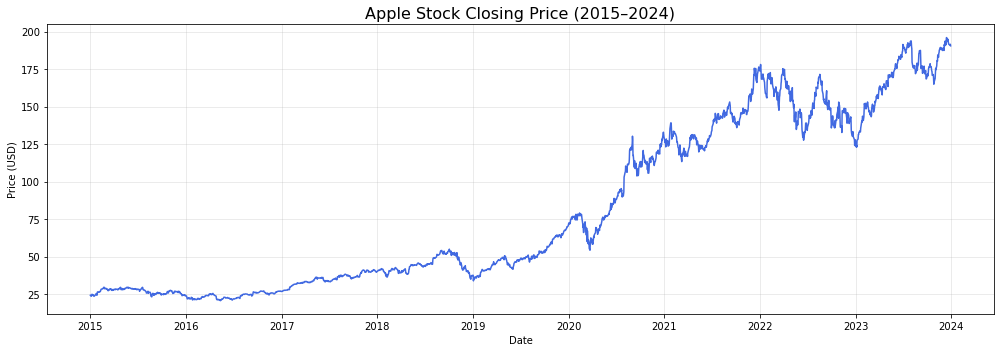

In [8]:
plt.figure(figsize=(14, 5))
plt.plot(df['Date'], df['Close'], color='royalblue', linewidth=1.5)
plt.title('Apple Stock Closing Price (2015–2024)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

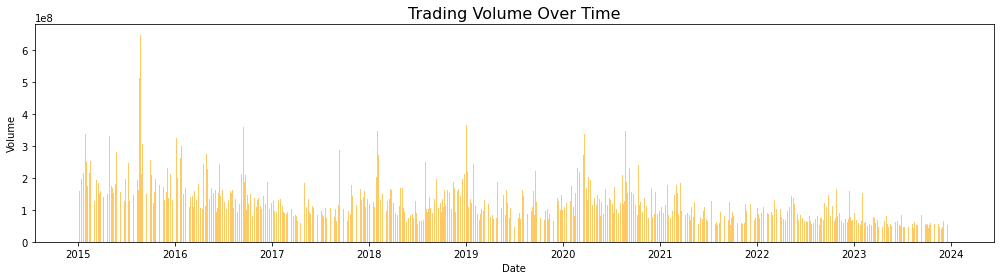

In [9]:
plt.figure(figsize=(14, 4))
plt.bar(df['Date'], df['Volume'], color='orange', alpha=0.6)
plt.title('Trading Volume Over Time', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Volume')
plt.tight_layout()
plt.show()

In [10]:
from sklearn.preprocessing import MinMaxScaler

# Use only Close price
close_prices = df[['Close']].values

# Scale between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(close_prices)

print("✅ Data scaled!")
print("First 5 scaled values:", scaled_data[:5])

✅ Data scaled!
First 5 scaled values: [[0.0206856 ]
 [0.01679832]
 [0.01681094]
 [0.01869148]
 [0.02391662]]


In [11]:
SEQ_LEN = 60  # Use last 60 days to predict next day

def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i - seq_len:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, SEQ_LEN)

# 80% train, 20% test
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Reshape for LSTM
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test  = X_test.reshape((X_test.shape[0],  X_test.shape[1],  1))

print("✅ Sequences created!")
print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")

✅ Sequences created!
Training samples : 1763
Testing samples  : 441


In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Reshape X for sklearn (it doesn't need the 3D shape)
X_train_2d = X_train.reshape(X_train.shape[0], X_train.shape[1])
X_test_2d  = X_test.reshape(X_test.shape[0],  X_test.shape[1])

# Build and train the model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_2d, y_train)

print("✅ Model trained successfully!")

✅ Model trained successfully!


In [16]:
# Predict
predicted_scaled = model.predict(X_test_2d).reshape(-1, 1)

# Convert back to original price scale
predicted_prices = scaler.inverse_transform(predicted_scaled)
actual_prices    = scaler.inverse_transform(y_test.reshape(-1, 1))

# Evaluate
mae  = mean_absolute_error(actual_prices, predicted_prices)
rmse = np.sqrt(mean_squared_error(actual_prices, predicted_prices))

print("📊 Model Evaluation:")
print(f"   MAE  (Mean Absolute Error) : ${mae:.2f}")
print(f"   RMSE (Root Mean Sq. Error) : ${rmse:.2f}")

📊 Model Evaluation:
   MAE  (Mean Absolute Error) : $6.09
   RMSE (Root Mean Sq. Error) : $9.11


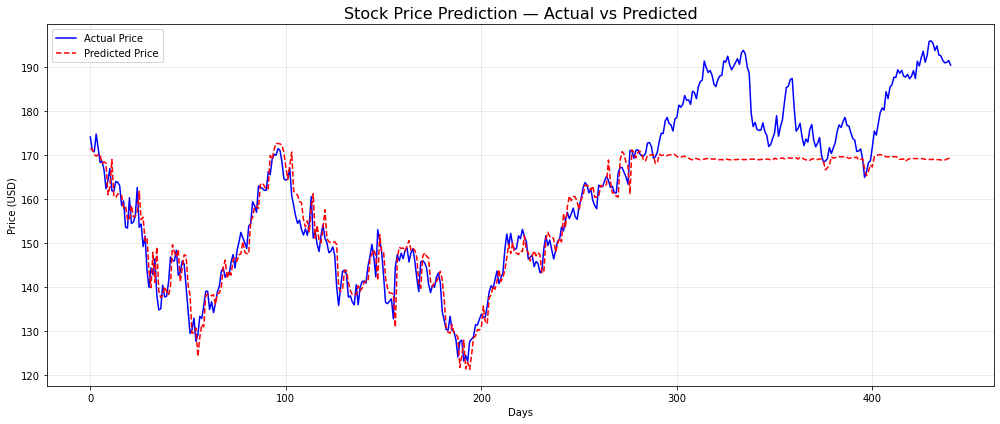

🎉Stock Price Predicted!


In [18]:
plt.figure(figsize=(14, 6))
plt.plot(actual_prices,    label='Actual Price',    color='blue', linewidth=1.5)
plt.plot(predicted_prices, label='Predicted Price', color='red',  linewidth=1.5, linestyle='--')
plt.title('Stock Price Prediction — Actual vs Predicted', fontsize=16)
plt.xlabel('Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("🎉Stock Price Predicted!")

In [19]:
# Save predictions to CSV
results = pd.DataFrame({
    'Actual Price':    actual_prices.flatten(),
    'Predicted Price': predicted_prices.flatten()
})
results.to_csv('stock_predictions.csv', index=False)
print("✅ Results saved to stock_predictions.csv")

✅ Results saved to stock_predictions.csv
